# Deep Learning

#### LSSTC DSFP Session 25

#### Rob Morgan

<a target="_blank" href="https://colab.research.google.com/github/LSSTC-DSFP/Session-25/blob/main/Day2/IntroductionToDeepLearning.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Earlier

Entering this lecture, we've covered a couple important concepts:

- The supervised ML workflow consists of the following steps:
    1. Prepare your data
    1. Establish training and testing data
    1. Train and tune your model with cross validation
    1. Measure the performance of your model
- Scikit-Learn has handy functions to streamline these steps

## This Talk

- Deep learning concepts
- Introducing PyTorch
- Deep networks for image data


## Perceptron Summary

![](https://uw-madison-datascience.github.io/2022-10-26-machine-learning-novice-sklearn/fig/perceptron.svg)

### How it works:

1.  **Inputs**: It takes multiple binary (or real-valued) inputs.
2.  **Weights**: Each input is multiplied by a corresponding weight, which signifies the importance of that input.
3.  **Weighted Sum**: All weighted inputs are summed up.
4.  **Activation Function**: This sum is then passed through an activation function. If the sum exceeds a certain threshold, the perceptron 'fires' (outputs 1) or remains 'dormant' (outputs 0 or -1).

These steps are also known as the "forward pass"



## Quick aside on activation functions

There are a bunch of them.


## Deep Learning Activation Functions

Activation functions are crucial components in artificial neural networks. They introduce non-linearity into the network, allowing it to learn complex patterns and relationships in the data. Without activation functions, a neural network would simply be a linear regression model, regardless of how many layers it had.

### Why Non-Linearity?

Linear models can only solve linearly separable problems. Most real-world data is non-linear. Activation functions transform the weighted sum of inputs from a neuron before passing it to the next layer, enabling the network to approximate any function it desires (Universal Approximation Theorem).

### Common Activation Functions



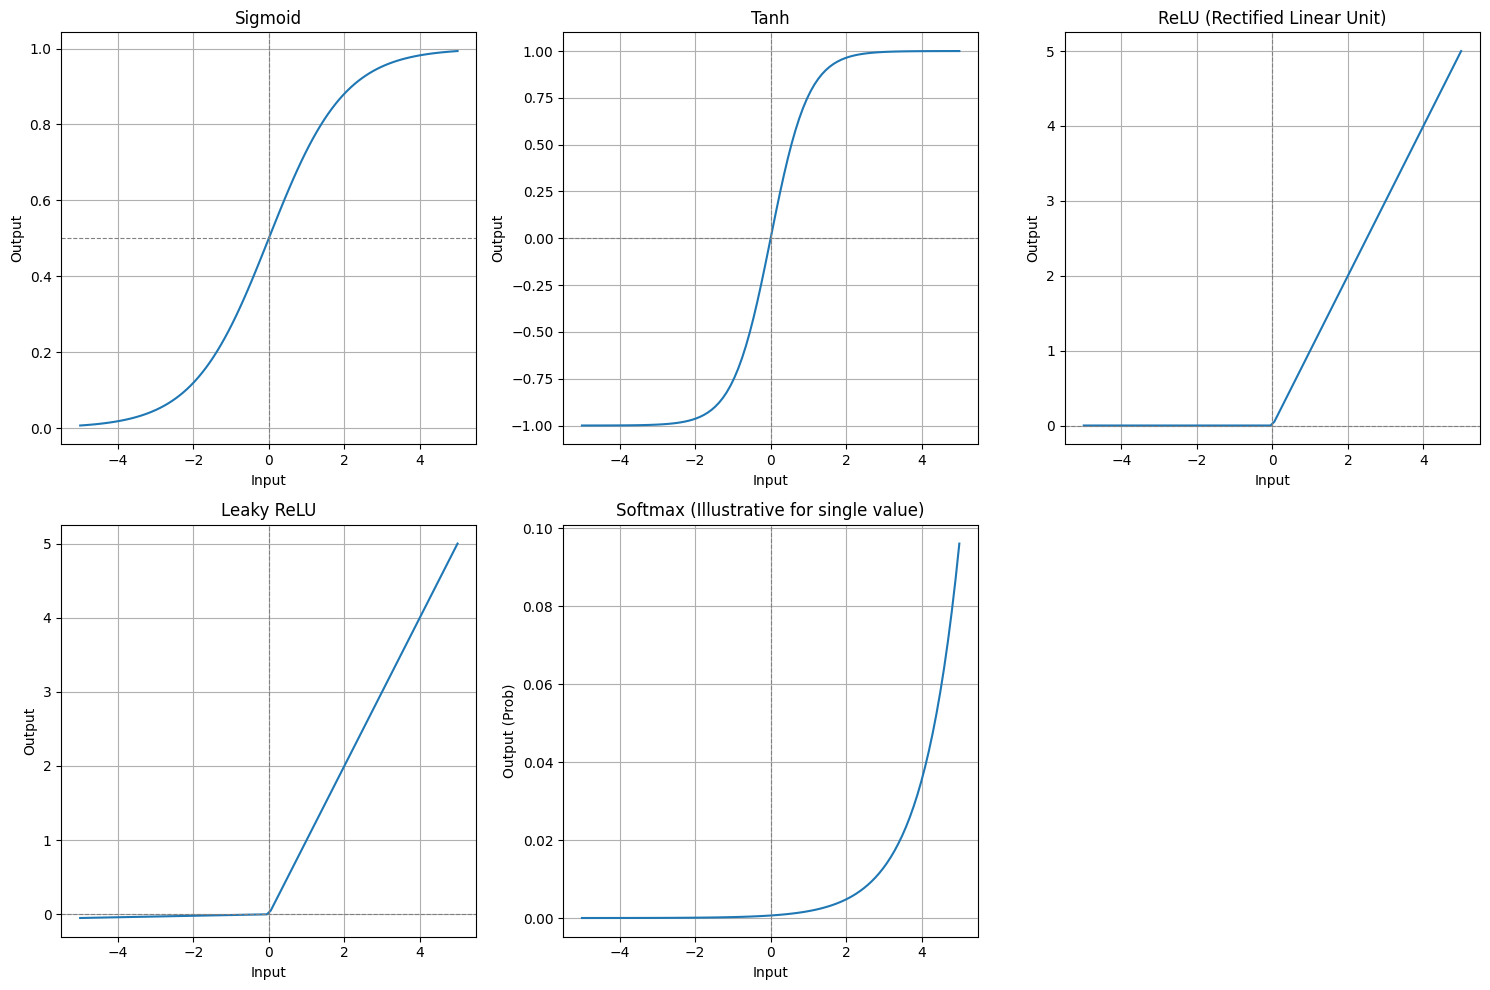


### Key Characteristics:

- **Sigmoid**: Squashes output between 0 and 1. Good for binary classification output layers, but suffers from vanishing gradients for very large/small inputs.
- **Tanh**: Squashes output between -1 and 1. Zero-centered, which can be beneficial, but also suffers from vanishing gradients.
- **ReLU**: Outputs the input directly if positive, otherwise zero. Very popular due to computational efficiency and mitigating vanishing gradients. Can suffer from 'dying ReLU' problem (neurons becoming inactive).
- **Leaky ReLU**: A variant of ReLU that allows a small, non-zero gradient when the input is negative, addressing the 'dying ReLU' issue.
- **Softmax**: Converts a vector of arbitrary real values into a probability distribution. Typically used in the output layer of a multi-class classification problem.

Choosing the right activation function depends on the network architecture and the specific problem you're trying to solve.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Concept Explanation
print("## Deep Learning Activation Functions\n")
print("Activation functions are crucial components in artificial neural networks. They introduce non-linearity into the network, allowing it to learn complex patterns and relationships in the data. Without activation functions, a neural network would simply be a linear regression model, regardless of how many layers it had.\n")
print("### Why Non-Linearity?\n")
print("Linear models can only solve linearly separable problems. Most real-world data is non-linear. Activation functions transform the weighted sum of inputs from a neuron before passing it to the next layer, enabling the network to approximate any function it desires (Universal Approximation Theorem).\n")

print("### Common Activation Functions\n")

# Define activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, x * alpha)

def softmax(x):
    # Softmax is typically used for output layers in multi-class classification
    # For visualization, we'll show its behavior for a single input range
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

# Generate a range of x values
x = np.linspace(-5, 5, 100)

# Plotting
plt.figure(figsize=(15, 10))

# Sigmoid
plt.subplot(2, 3, 1)
plt.plot(x, sigmoid(x))
plt.title('Sigmoid')
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

# Tanh
plt.subplot(2, 3, 2)
plt.plot(x, tanh(x))
plt.title('Tanh')
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# ReLU
plt.subplot(2, 3, 3)
plt.plot(x, relu(x))
plt.title('ReLU (Rectified Linear Unit)')
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Leaky ReLU
plt.subplot(2, 3, 4)
plt.plot(x, leaky_relu(x))
plt.title('Leaky ReLU')
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Softmax (illustrative for a single input range)
# Note: Softmax typically operates on a vector of inputs.
# Here, we're just showing the shape for one value, which isn't its full utility.
plt.subplot(2, 3, 5)
plt.plot(x, softmax(x))
plt.title('Softmax (Illustrative for single value)')
plt.xlabel('Input')
plt.ylabel('Output (Prob)')
plt.grid(True)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print("\n### Key Characteristics:\n")
print("- **Sigmoid**: Squashes output between 0 and 1. Good for binary classification output layers, but suffers from vanishing gradients for very large/small inputs.")
print("- **Tanh**: Squashes output between -1 and 1. Zero-centered, which can be beneficial, but also suffers from vanishing gradients.")
print("- **ReLU**: Outputs the input directly if positive, otherwise zero. Very popular due to computational efficiency and mitigating vanishing gradients. Can suffer from 'dying ReLU' problem (neurons becoming inactive).")
print("- **Leaky ReLU**: A variant of ReLU that allows a small, non-zero gradient when the input is negative, addressing the 'dying ReLU' issue.")
print("- **Softmax**: Converts a vector of arbitrary real values into a probability distribution. Typically used in the output layer of a multi-class classification problem.")

print("\nChoosing the right activation function depends on the network architecture and the specific problem you're trying to solve.")


## Breakout Problem

Most networks utilize the ReLU activation function internally. Why do you think that might be? What makes it stand out from the sigmoid and tanh functions? Why might that characteristic be advantageous?

Discuss your ideas with your partner.

## Aside Over, Back to Perceptrons

## How does the perceptron learn?

Or rather, how do we update the weights?

In Adam's lecture, we used this formula:

*   **New Weight** ($w_i^{new}$) = **Old Weight** ($w_i^{old}$) + $\alpha \times (y - \hat{y}) \times x_i$
*   **New Bias** ($b^{new}$) = **Old Bias** ($b^{old}$) + $\alpha \times (y - \hat{y})$

We evaluate how right or wrong the classifications are, and update the weights accordingly.

So, the $(y - \hat{y})$ term makes sense intuitively, but where does it come from mathematically?



## Evaluating Classifications

A popular way of evaluating differences is the Mean Squared Error

*   **Mean Squared Error (MSE)**:
    *   $\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

The statisticians among us may recall this originates from some Gaussian distribution math assuming errors are normally distributed.

## Updating Weights

Our goal is to minimize the MSE.

To minimize things, you take their derivative (gradient), and this is where the $(y - \hat{y})$ term comes from.

## The Components of the Learning Process

1. Forward pass
    - Apply weights to data
    - Sum the weights and bias
    - Pass through an activation function

1. Loss function
    - Evaluate the correctness of your classifications

1. Back-propagation
    - Compute gradients of loss
    - Update weights

1. Repeat


## From Perceptrons to Networks

In the problems from yesterday, you were asked to think about why a random forest outperformed a decision tree.

The same principle applies here: ensemble classifiers.

$$
P = \sum_{k=ceil(N/2)}^{N} \binom{N}{k} p^{k} (1-p)^{N-k}
$$

As long as $p>0.5$, having independent classifiers combine their predictions will always be an improvement.


Two perceptrons voting:

![](https://uw-madison-datascience.github.io/2022-10-26-machine-learning-novice-sklearn/fig/perceptron.svg)

![](https://uw-madison-datascience.github.io/2022-10-26-machine-learning-novice-sklearn/fig/perceptron.svg)

Now what if we want one of the perceptron's vote to matter more than the others?

To achieve that we would apply weights to the votes and then aggregate them together.

Sounds familiar....

Probability increases the more classifiers we have, right? So let's have more voters.

image

And we probably don't want to rely on just one vote counter right? I mean, why should they have all the fun.

image

This also enables different weights.

See where I'm going?

You can extend your network to have many layers and lots of nodes per layer, and before you know it, you're deep learning.

Alright, let's write some code.

## Introducing PyTorch

### Key Differences: Scikit-Learn vs. PyTorch
1. **Explicit Architecture**: While sklearn uses pre-defined estimators (e.g., `RandomForestClassifier`), PyTorch requires you to define the network architecture manually.
2. **Tensors**: PyTorch operates on `torch.Tensor` objects, which are similar to NumPy arrays but support automatic differentiation and GPU acceleration.
3. **Optimization Loop**: In sklearn, `.fit()` handles everything. In PyTorch, you will manually write the training loop, including the forward pass, loss calculation, backpropagation, and weight updates.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Part 1: Data Preparation

In neural networks, data scaling is critical because we use gradient-based optimization. We'll start with a synthetic dataset (the 'Moons' dataset) to visualize the decision boundary.

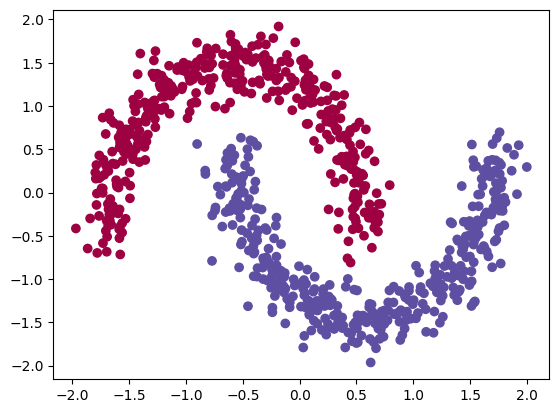

In [2]:
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

plt.figure()
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.Spectral)
plt.show()

In [3]:
# Convert to PyTorch Tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1).to(device)

## Part 2: Defining the Architecture

In PyTorch, we define a class for our classifier. This requires two main methods:
1. `__init__`: Define the layers (the 'anatomy' of the network).
2. `forward`: Define how data flows through these layers.

### Example: Simple Multi-Layer Perceptron (MLP)
We will create a network with one hidden layer of 10 neurons and a ReLU activation function.

In [4]:
class SimpleNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNet, self).__init__()
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

        # Define activations
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Define the flow of data
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Instantiate the model
model = SimpleNet(
    input_size=2,              # 2 features (x and y coordinate).
    hidden_size=10,            # 10 nodes in the layer.
    output_size=1).to(device)  # Make a final classification.
print(model)

SimpleNet(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [5]:
class LessSimpleNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LessSimpleNet, self).__init__()
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size) # New!
        self.fc3 = nn.Linear(hidden_size, output_size)

        # Define activations
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Define the flow of data
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)     # Add it to the flow.
        x = self.relu(x)    # Add an activation.
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

# Instantiate the model
model = LessSimpleNet(
    input_size=2,              # 2 features (x and y coordinate).
    hidden_size=10,            # 10 nodes in the layer.
    output_size=1).to(device)  # Make a final classification.
print(model)

LessSimpleNet(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


## Part 3: The Training Loop

Unlike sklearn's `.fit()`, we must explicitly:
1. Choose a **Loss Function** (e.g., Binary Cross Entropy).
2. Choose an **Optimizer** (e.g., SGD or Adam).
3. Iterate through epochs: Clear gradients -> Forward pass -> Calculate Loss -> Backward pass (Backprop) -> Update weights.

Epoch [10/100], Loss: 0.6144
Epoch [20/100], Loss: 0.4359
Epoch [30/100], Loss: 0.2897
Epoch [40/100], Loss: 0.2569
Epoch [50/100], Loss: 0.2434
Epoch [60/100], Loss: 0.2260
Epoch [70/100], Loss: 0.2149
Epoch [80/100], Loss: 0.2083
Epoch [90/100], Loss: 0.2035
Epoch [100/100], Loss: 0.2004


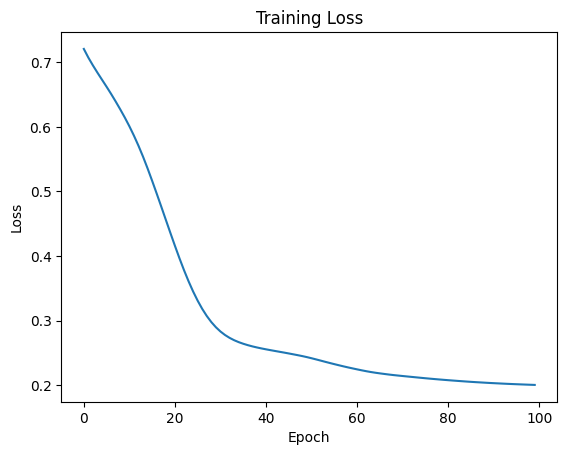

In [6]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
losses = []

for epoch in range(epochs):
    # 1. Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # 2. Backward pass and optimization
    optimizer.zero_grad() # Clear previous gradients
    loss.backward()      # Compute gradients
    optimizer.step()     # Update weights

    losses.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [9]:
# Making predictions.

model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)

from sklearn.metrics import classification_report

if device.type == 'cuda':
    y_pred = y_pred.cpu()

print(classification_report(y_test, y_pred.round()))

              precision    recall  f1-score   support

           0       0.95      0.84      0.89       100
           1       0.86      0.96      0.91       100

    accuracy                           0.90       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.90      0.90       200



## Convolutional Neural Networks

Image classification is a rich field and CNNs are the main tool in this space.

Images are two-dimensional, sometimes more (like if you have multiple filters in optical astronomy).

The networks we build need to be adapted to extract information from 2+ dimensional inputs.

### Main components of CNNs

1. **`nn.Conv2d`**: Learns spatial filters.
2. **`nn.MaxPool2d`**: Reduces dimensionality (downsampling).
3. **Flattening**: The bridge between convolutional layers and the final classification layers.

![](https://www.researchgate.net/publication/335577712/figure/fig1/AS:799052589441025@1567520391598/Example-for-convolution-and-max-pooling-operation.png)

Image Credit: Schäfer 2019. 10.1002/cite.201900099.

## Breakout Problem

I just introduced the matrix operations of convolution and pooling and claimed you can build a network based on them.

Why do you think these operations are useful? Can you describe what they accomplish?

Discuss with your partner.

## A Simple CNN

In [10]:
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.fc1 = nn.Linear(1600, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = x.view(-1, 1600) # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## Let's see it in action!

In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Standard MNIST transform
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)

# Images are bigger and won't all fit in memory at the same time.
# The `DataLoader` sends data through the network in batches.
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.07MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.85MB/s]


In [20]:
def train_cnn(model, device, train_loader, optimizer, epoch):
    model.train() # Set the model to training mode
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target) # Negative Log Likelihood Loss for classification
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0: # Print loss every 100 batches
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

def test_cnn(model, device, test_loader):
    model.eval() # Set the model to evaluation mode
    test_loss = 0
    correct = 0
    with torch.no_grad(): # Disable gradient calculation for evaluation
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item() # Sum up batch loss
            pred = output.argmax(dim=1, keepdim=True) # Get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset):.0f}%)\n')


In [21]:
# Load the test dataset (using the same transform)
test_set = datasets.MNIST('./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=1000, shuffle=False) # Use a larger batch size for testing

# Instantiate the CNN model
cnn_model = SimpleCNN().to(device)

# Define Optimizer and Loss Function (already defined F.nll_loss in train_cnn)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.01)

# Run the training loop for the CNN
epochs_cnn = 5 # Fewer epochs for demonstration
for epoch in range(1, epochs_cnn + 1):
    train_cnn(cnn_model, device, train_loader, cnn_optimizer, epoch)
    test_cnn(cnn_model, device, test_loader)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.304299
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.174822
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.364797
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.150098
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.122936
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.136627
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.062116
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.060285
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.046392
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.065278

Test set: Average loss: 0.1151, Accuracy: 9651/10000 (97%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.116724
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.278336
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.183012
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.015077
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.060937
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.098139
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.090902
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.021598
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.054607
T

## Some Popular Architectures

1998: LeNet-5

Probably the first widely used CNN. Successful on MNIST.

![](https://media.geeksforgeeks.org/wp-content/uploads/20230215093923/CNN-Architectures-1.png)

2012: AlexNNet

First network to stack convolutional layers, use ReLU activations, and leverage GPUs. Successful on ImageNet.

![](https://media.geeksforgeeks.org/wp-content/uploads/20230215094135/CNN-Architectures-2.png)

2014: GoogleNet

Presented the Inception module.

![](https://media.geeksforgeeks.org/wp-content/uploads/20200429201304/Incepption-module.PNG)

2015: ResNet

Introduced identity as a feature

![](https://media.geeksforgeeks.org/wp-content/uploads/20200424011510/Residual-Block.PNG)




## Summary

We'll still use our "Supervised ML Workflow," but now PyTorch is the tool we'll use.

This means

  - Data stored in Tensors, managed in DataLoaders
  - Create a Class for your network
  - Implement the `__init__` and `forward` methods
  - Pick your loss function and optimizer
  - Write a training loop
  - Measure your trained network on test data


Happy networking!



# Appendix

Below is some Rob + Gemini content. I'm leaving it out of the main lecture slides, but I thought is was a nice summary of some foundational concepts.

## Perceptron Summary

A **perceptron** is the simplest form of an artificial neural network, acting as a linear classifier. It's a fundamental building block of more complex neural networks.

### How it works:

1.  **Inputs**: It takes multiple binary (or real-valued) inputs.
2.  **Weights**: Each input is multiplied by a corresponding weight, which signifies the importance of that input.
3.  **Weighted Sum**: All weighted inputs are summed up.
4.  **Activation Function**: This sum is then passed through an activation function (often a step function or sign function). If the sum exceeds a certain threshold (or a bias term is added and the sum is evaluated), the perceptron 'fires' (outputs 1) or remains 'dormant' (outputs 0 or -1).

### Key Characteristics:

*   It can learn to classify linearly separable data.
*   It forms the basis for understanding how more complex neural networks make decisions.
*   It was developed in the late 1950s by Frank Rosenblatt.

While limited in its ability to solve non-linearly separable problems (like XOR), the perceptron laid the groundwork for modern deep learning.

![](https://uw-madison-datascience.github.io/2022-10-26-machine-learning-novice-sklearn/fig/perceptron.svg)

## Perceptron Weight Update using Stochastic Gradient Descent (SGD)

For a perceptron, the goal during training is to find the optimal set of weights (and bias) that allow it to correctly classify the input data. Stochastic Gradient Descent (SGD) is a common algorithm used to update these weights.

### The Perceptron Learning Rule

The perceptron learning rule is a specific type of SGD. It updates the weights and bias *incrementally* after each misclassified training example. The update rule is as follows:

*   **New Weight** ($w_i^{new}$) = **Old Weight** ($w_i^{old}$) + $\alpha \times (y - \hat{y}) \times x_i$
*   **New Bias** ($b^{new}$) = **Old Bias** ($b^{old}$) + $\alpha \times (y - \hat{y})$

Where:
*   $w_i$: The weight corresponding to input feature $x_i$
*   $b$: The bias term
*   $\alpha$: The learning rate (a small positive value, typically between 0.01 and 0.1), which controls the step size of the update.
*   $y$: The *true* target output for the current training example.
*   $\hat{y}$: The *predicted* output from the perceptron for the current training example.
*   $x_i$: The $i$-th input feature value for the current training example.

### How it works (SGD for Perceptron):

1.  **Initialization**: Start with small random weights and a bias (or zeros).
2.  **Iterate over training examples (epochs)**:
    a.  For each training example $(x, y)$:
        i.   **Predict**: Calculate the perceptron's output $\hat{y}$.
        ii.  **Compare**: Check if the prediction $\hat{y}$ matches the true label $y$.
        iii. **Update (if misclassified)**: If $y \neq \hat{y}$:
             *   If the perceptron predicted 0 (or -1) but the true label was 1, the weights and bias are *increased* proportionally to the input features to make the perceptron more likely to fire for similar inputs.
             *   If the perceptron predicted 1 but the true label was 0 (or -1), the weights and bias are *decreased* proportionally to the input features to make the perceptron less likely to fire.

This process continues for a fixed number of epochs or until the perceptron correctly classifies all training examples (for linearly separable data). The 'stochastic' part comes from updating the weights based on *each individual* training example, rather than the entire batch or dataset.

In [3]:
import numpy as np

class Perceptron:
    def __init__(self, learning_rate=0.01, n_iterations=100):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Convert labels to -1 and 1 if they are 0 and 1
        # This is common for perceptrons with a sign activation function
        y_ = np.where(y == 0, -1, 1)

        for _ in range(self.n_iterations):
            for idx, x_i in enumerate(X):
                # Calculate activation
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = np.where(linear_output >= 0, 1, -1)

                # Perceptron Update Rule (SGD)
                update = self.learning_rate * (y_[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, -1)

# --- Demo with a simple dataset ---

# Linearly separable data (XOR-like but simplified for linear separability)
# Class 0: (0,0), (0,1)
# Class 1: (1,0), (1,1)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 0, 1, 1]) # Target labels

print("Training a Perceptron...")
perceptron = Perceptron(learning_rate=0.1, n_iterations=10)
perceptron.fit(X, y)

print("\nPerceptron trained.")
print(f"Final Weights: {perceptron.weights}")
print(f"Final Bias: {perceptron.bias}")

# Make predictions
predictions = perceptron.predict(X)
print("\nPredictions for training data (expected: [-1, -1, 1, 1] if y=0 is -1, y=1 is 1):")
print(predictions)

# Convert original y to -1, 1 for comparison
y_comparison = np.where(y == 0, -1, 1)
accuracy = np.mean(predictions == y_comparison)
print(f"Accuracy on training data: {accuracy * 100:.2f}%")

# Example with a new point
new_point = np.array([0.5, 0.5])
new_prediction = perceptron.predict(new_point.reshape(1, -1))
print(f"\nPrediction for new point {new_point}: {new_prediction[0]} (1 indicates Class 1, -1 indicates Class 0)")


Training a Perceptron...

Perceptron trained.
Final Weights: [0.2 0. ]
Final Bias: -0.2

Predictions for training data (expected: [-1, -1, 1, 1] if y=0 is -1, y=1 is 1):
[-1 -1  1  1]
Accuracy on training data: 100.00%

Prediction for new point [0.5 0.5]: -1 (1 indicates Class 1, -1 indicates Class 0)


## Backpropagation

**Backpropagation** (short for "backward propagation of errors") is the fundamental algorithm used to train artificial neural networks. It's an iterative process that adjusts the weights and biases of a neural network to minimize the difference between the network's predicted output and the true output.

### The Goal

The primary goal of backpropagation is to efficiently compute the **gradient** of the loss function with respect to each weight and bias in the network. Once these gradients are known, optimization algorithms like Stochastic Gradient Descent (SGD) can be used to update the weights and biases in the direction that reduces the loss.

### Why is it needed?

Neural networks learn by making predictions, comparing them to actual values, and then adjusting their internal parameters (weights and biases) to make better predictions next time. This adjustment process relies on knowing *how much* each parameter contributed to the error. Backpropagation provides a systematic way to calculate this contribution, propagating the error backward from the output layer to the input layer.

### How it works (The Two Passes):

Backpropagation involves two main phases:

1.  **Forward Pass**:
    *   Input data is fed into the network.
    *   It passes through each layer, with neurons performing weighted sums and applying activation functions.
    *   This generates an output prediction $(\hat{y})$.
    *   The loss (error) between the prediction $(\hat{y})$ and the true target $(y)$ is calculated.

2.  **Backward Pass (Backpropagation of Error)**:
    *   The calculated loss is used to compute the *gradient* of the loss with respect to the output layer's weights and biases.
    *   These gradients are then propagated backward through the network, layer by layer.
    *   Using the **chain rule of calculus**, the gradients for the weights and biases of each hidden layer are calculated.
    *   This tells us how much each weight and bias contributed to the overall error.

### The Math (Intuition):

The core idea is to find $\frac{\partial L}{\partial w}$, where $L$ is the loss and $w$ is a weight. If a weight $w$ affects an activation $a$, and $a$ affects the loss $L$, then by the chain rule:

$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a} \times \frac{\partial a}{\partial w}$

Backpropagation systematically applies this chain rule across all layers, reusing computed gradients to avoid redundant calculations, making it computationally efficient.

### Steps in Detail:

1.  **Initialize Weights and Biases**: Randomly initialize all weights and biases in the network.
2.  **Forward Propagation**:
    *   For each training example, calculate the output of each neuron from the input layer to the output layer.
    *   Store intermediate values (like weighted sums and activations) as they are needed in the backward pass.
3.  **Calculate Loss**: Compute the loss between the network's output and the true label.
4.  **Backward Propagation of Errors**:
    *   Calculate the error gradient for the output layer's activations and then its weights and biases.
    *   Propagate these error gradients backward to the previous layer, calculating the error gradient for that layer's activations.
    *   Repeat this process until the input layer is reached, computing gradients for all weights and biases.
5.  **Update Weights and Biases**: Use an optimization algorithm (like SGD) to update each weight and bias by subtracting a fraction (learning rate) of its gradient.
    *   $w_{new} = w_{old} - \alpha \times \frac{\partial L}{\partial w}$
    *   $b_{new} = b_{old} - \alpha \times \frac{\partial L}{\partial b}$
6.  **Repeat**: Repeat steps 2-5 for multiple epochs (passes over the entire dataset) until the network converges or a stopping criterion is met.

Backpropagation is a powerful algorithm that enables neural networks to learn from data and solve complex problems by iteratively refining their internal parameters.

## Loss Functions in Artificial Neural Networks

**Loss functions** (also known as cost functions or error functions) are a fundamental component of artificial neural networks and machine learning in general. Their primary purpose is to quantify the difference between the predicted output of a model and the true (or desired) output. This quantitative measure of error is then used to guide the learning process of the neural network.

### Why are Loss Functions Important?

1.  **Optimization Target**: During the training of a neural network, the goal is to minimize this loss value. Optimization algorithms (like Gradient Descent and its variants) use the gradients of the loss function with respect to the network's weights and biases to iteratively adjust these parameters.
2.  **Performance Metric**: The loss function serves as a direct indicator of how well the model is performing on the training data. A lower loss generally means a better-performing model.
3.  **Guiding Learning**: By calculating the error, the loss function tells the network *how much* and in *what direction* to adjust its internal parameters to reduce future errors.

### Key Characteristics of a Good Loss Function:

*   **Differentiable**: For gradient-based optimization methods (like backpropagation), the loss function must be differentiable with respect to the model's output and, by extension, its weights and biases.
*   **Convex (ideally)**: While not always achievable in complex neural networks, a convex loss function simplifies the optimization problem as it guarantees a single global minimum.
*   **Reflects Problem Goal**: The choice of loss function should align with the specific task the neural network is trying to solve (e.g., regression, classification).

### Common Types of Loss Functions:

Loss functions are typically chosen based on the type of problem being solved:

#### 1. Regression Problems (Predicting Continuous Values)

*   **Mean Squared Error (MSE)** / **L2 Loss**:
    *   Formula: $L = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$
    *   Description: Calculates the average of the squared differences between predicted and true values. It heavily penalizes large errors. Works well when predictions should be very close to the true values.

*   **Mean Absolute Error (MAE)** / **L1 Loss**:
    *   Formula: $L = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$
    *   Description: Calculates the average of the absolute differences between predicted and true values. Less sensitive to outliers than MSE, as it doesn't square the errors.

*   **Huber Loss**:
    *   Description: A combination of MSE and MAE. It's quadratic for small errors (like MSE) and linear for large errors (like MAE), making it less sensitive to outliers than MSE while providing smooth gradients around the minimum.

#### 2. Classification Problems (Predicting Categories)

*   **Binary Cross-Entropy (BCE)**:
    *   Used for binary classification (two classes).
    *   Formula: $L = -\frac{1}{n} \sum_{i=1}^{n} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$
    *   Description: Penalizes predictions that are confident and wrong heavily. It's suitable when the output layer uses a sigmoid activation function.

*   **Categorical Cross-Entropy (CCE)**:
    *   Used for multi-class classification where each sample belongs to *exactly one* class (one-hot encoded labels).
    *   Formula: $L = -\frac{1}{n} \sum_{i=1}^{n} \sum_{j=1}^{C} y_{ij} \log(\hat{y}_{ij})$
    *   Description: Similar to BCE but extended for multiple classes. It's suitable when the output layer uses a softmax activation function.

*   **Sparse Categorical Cross-Entropy**:
    *   Used for multi-class classification when labels are integers (not one-hot encoded).
    *   Description: Essentially the same calculation as CCE but handles integer labels directly, converting them internally to one-hot encoding.

*   **Hinge Loss**:
    *   Used primarily for Support Vector Machines (SVMs) but can be used with neural networks for classification.
    *   Formula: $L = \max(0, 1 - y_i \hat{y}_i)$
    *   Description: Aims to not only classify correctly but also ensure that correct classifications have a certain margin of confidence. It pushes the true class score to be at least 1 greater than the incorrect class scores.

### In Summary:

Loss functions are the guiding light for neural networks during training. They provide the quantitative feedback necessary for the network to learn and improve its predictions by adjusting its internal parameters through optimization algorithms like backpropagation.